<a href="https://colab.research.google.com/github/Nik-gif-dev/Demo1/blob/main/clinical_term_disambiguation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub sentence-transformers scikit-learn nltk

In [2]:
import kagglehub

path = kagglehub.dataset_download("tboyle10/medicaltranscriptions")

print("Dataset path:", path)

Using Colab cache for faster access to the 'medicaltranscriptions' dataset.
Dataset path: /kaggle/input/medicaltranscriptions


In [3]:
import pandas as pd
import os

file_path = os.path.join(path, "mtsamples.csv")

df = pd.read_csv(file_path)

df = df.dropna(subset=["transcription"])

print(df.head())

   Unnamed: 0                                        description  \
0           0   A 23-year-old white female presents with comp...   
1           1           Consult for laparoscopic gastric bypass.   
2           2           Consult for laparoscopic gastric bypass.   
3           3                             2-D M-Mode. Doppler.     
4           4                                 2-D Echocardiogram   

             medical_specialty                                sample_name  \
0         Allergy / Immunology                         Allergic Rhinitis    
1                   Bariatrics   Laparoscopic Gastric Bypass Consult - 2    
2                   Bariatrics   Laparoscopic Gastric Bypass Consult - 1    
3   Cardiovascular / Pulmonary                    2-D Echocardiogram - 1    
4   Cardiovascular / Pulmonary                    2-D Echocardiogram - 2    

                                       transcription  \
0  SUBJECTIVE:,  This 23-year-old white female pr...   
1  PAST MEDICAL 

In [4]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["clean_text"] = df["transcription"].apply(preprocess)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(df["clean_text"].tolist(), show_progress_bar=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/156 [00:00<?, ?it/s]

In [6]:
from sklearn.cluster import KMeans

num_clusters = 10

kmeans = KMeans(n_clusters=num_clusters, random_state=42)

clusters = kmeans.fit_predict(embeddings)

df["sense_cluster"] = clusters

In [7]:
import numpy as np
from sklearn.metrics import accuracy_score

true_labels = df["medical_specialty"].values
clusters = df["sense_cluster"].values

cluster_to_label = {}

for c in np.unique(clusters):
    labels_in_cluster = true_labels[clusters == c]

    # find most frequent label
    values, counts = np.unique(labels_in_cluster, return_counts=True)
    cluster_to_label[c] = values[np.argmax(counts)]

# convert clusters to predicted labels
predicted_labels = [cluster_to_label[c] for c in clusters]

# compute accuracy
sense_accuracy = accuracy_score(true_labels, predicted_labels)

print("Sense Accuracy:", sense_accuracy)

Sense Accuracy: 0.3415223519935562


In [8]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

similarity_matrix = cosine_similarity(embeddings)

scores = []

for i in range(len(df)):
    same_cluster = df["sense_cluster"] == df["sense_cluster"].iloc[i]
    idx = np.where(same_cluster)[0]
    if len(idx) > 1:
        scores.append(np.mean(similarity_matrix[i][idx]))

context_matching_score = np.mean(scores)

print("Context Matching Score:", context_matching_score)

Context Matching Score: 0.54615015


In [10]:
df[["medical_specialty","sense_cluster","transcription"]].head(20)

,medical_specialty,sense_cluster,transcription
0,Allergy / Immunology,2,"SUBJECTIVE:, This 23-year-old white female pr..."
1,Bariatrics,7,"PAST MEDICAL HISTORY:, He has difficulty climb..."
2,Bariatrics,7,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ..."
3,Cardiovascular / Pulmonary,6,"2-D M-MODE: , ,1. Left atrial enlargement wit..."
4,Cardiovascular / Pulmonary,6,1. The left ventricular cavity size and wall ...
5,Bariatrics,9,"PREOPERATIVE DIAGNOSIS: , Morbid obesity.,POST..."
6,Bariatrics,9,"PREOPERATIVE DIAGNOSES:,1. Deformity, right b..."
7,Cardiovascular / Pulmonary,6,"2-D ECHOCARDIOGRAM,Multiple views of the heart..."
8,Bariatrics,9,"PREOPERATIVE DIAGNOSIS: , Lipodystrophy of the..."
9,Cardiovascular / Pulmonary,6,"DESCRIPTION:,1. Normal cardiac chambers size...."


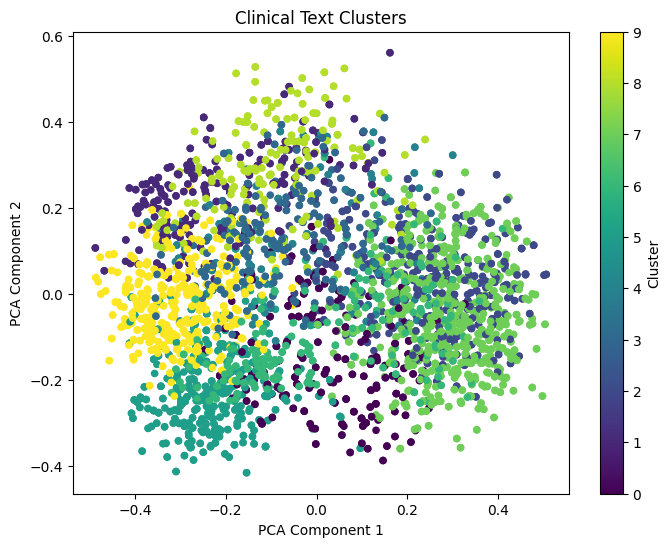

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(reduced_embeddings[:,0],
            reduced_embeddings[:,1],
            c=df["sense_cluster"],
            cmap="viridis",
            s=20)

plt.title("Clinical Text Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()

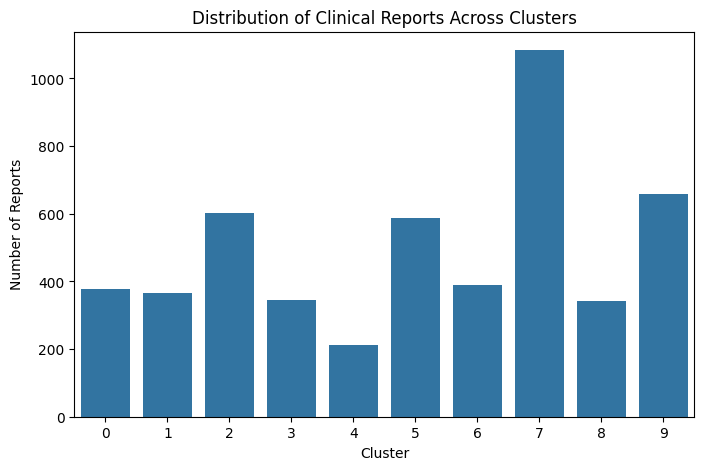

In [12]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x=df["sense_cluster"])

plt.title("Distribution of Clinical Reports Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Reports")

plt.show()

In [15]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize and fit TfidfVectorizer on the entire clean_text
# This 'vectorizer' will be used to get word features.
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df["clean_text"])
terms = vectorizer.get_feature_names_out()

for i in range(num_clusters): # Use num_clusters from previous cell
    # Create a boolean mask for documents belonging to the current cluster
    cluster_mask = (df["sense_cluster"] == i)

    # Get the TF-IDF matrix for documents in this cluster using the boolean mask
    cluster_tfidf_matrix = tfidf_matrix[cluster_mask.to_numpy()]

    # Sum TF-IDF scores for each term across all documents in the cluster
    # This gives an aggregated importance score for each word in the cluster
    sum_tfidf_scores = cluster_tfidf_matrix.sum(axis=0)

    # Convert to a dense array for easier sorting
    sum_tfidf_scores_dense = np.array(sum_tfidf_scores).flatten()

    # Get the indices of the top 10 terms for this cluster
    top_term_indices = sum_tfidf_scores_dense.argsort()[-10:][::-1] # [::-1] to get in descending order

    # Get the actual top 10 terms
    top_words = [terms[idx] for idx in top_term_indices]

    print(f"Cluster {i} keywords:", top_words)

Cluster 0 keywords: ['pain', 'right', 'left', 'cervical', 'spine', 'patient', 'knee', 'disc', 'cc', 'normal']
Cluster 1 keywords: ['uterus', 'patient', 'placed', 'uterine', 'incision', 'cord', 'cervix', 'vicryl', 'fascia', 'cm']
Cluster 2 keywords: ['patient', 'normal', 'history', 'right', 'left', 'mg', 'time', 'exam', 'also', 'without']
Cluster 3 keywords: ['lobe', 'patient', 'right', 'left', 'chest', 'tube', 'pleural', 'procedure', 'lung', 'upper']
Cluster 4 keywords: ['bladder', 'patient', 'prostate', 'renal', 'ureteral', 'right', 'stone', 'urethra', 'kidney', 'placed']
Cluster 5 keywords: ['patient', 'placed', 'cc', 'left', 'right', 'using', 'bone', 'medial', 'wound', 'carpal']
Cluster 6 keywords: ['artery', 'coronary', 'left', 'right', 'ventricular', 'aortic', 'valve', 'catheter', 'patient', 'normal']
Cluster 7 keywords: ['history', 'patient', 'mg', 'pain', 'normal', 'denies', 'daily', 'blood', 'negative', 'day']
Cluster 8 keywords: ['colon', 'scope', 'patient', 'gallbladder', 'pr